In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

from src import tokenizer
from src.base_plm import ProteinLanguageModel

In [3]:
def read_fasta(path: str = "datasets/homeodomain_seed.fasta") -> list[SeqRecord]:
    with open(path) as p:
        records = list(SeqIO.parse(p, "fasta"))
    return records


def tokenize_seqrecords(seq_records: list[SeqRecord]) -> list[np.ndarray]:
    return [tokenizer.tokenize(seq.seq) for seq in seq_records]


def plot_loss(loss_vals: list[float], path: str = "figures/loss.png"):
    plt.plot(range(len(loss_vals)), loss_vals)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig(path)

In [4]:
sequence = "RARY"
tokenized = tokenizer.tokenize(sequence)
print(tokenized)
detokenized = tokenizer.de_tokenize(tokenized)
print(detokenized)

[ 1  0  1 18]
RARY


In [5]:
path = "../datasets/homeodomain_seed.fasta"
with open(path) as p:
    records = list(SeqIO.parse(p, "fasta"))

tokenized = tokenize_seqrecords(records)
print(records[1])
print(tokenized[1])

ID: VENTX_HUMAN/92-148
Name: VENTX_HUMAN/92-148
Description: VENTX_HUMAN/92-148
Number of features: 0
Seq('PRVRTAFTMEQVRTLEGVFQHHQYLSPLERKRLAREMQLSEVQIKTWFQNRRMKHKR')
[14  1 22  1 16  0 13 16 12  6  5 22  1 16 10  6  7 22 13  5  8  8  5 18
 10 15 14 10  6  1 11  1 10  0  1  6 12  5 10 15  6 22  5  9 11 16 17 13
  5  2  1  1 12 11  8 11  1]


In [6]:
vocab_size = len(tokenizer.KEYS)
model = ProteinLanguageModel(
    vocab_size=vocab_size, embedding_dim=128, num_heads=4, num_layers=4
)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
np.random.seed(42)

train_portion = 0.7
train_n = int(len(records) * train_portion)
num_epochs = 1000 // train_n
loss_vals = [0 for n in range(num_epochs)]

np.random.shuffle(tokenized)
train_subset = tokenized[0:train_n]
test_subset = tokenized[train_n : len(tokenized)]

train_subset_tensor = [torch.tensor(seq) for seq in train_subset]

# Pad sequences (batch_first=True gives shape: (batch_size, seq_len))
X_train = torch.nn.utils.rnn.pad_sequence(
    train_subset_tensor, batch_first=True, padding_value=tokenizer.PAD_TOKEN
)

print(f"Shape of X_train: {X_train.shape}")  # (train_n, max_len)

Shape of X_train: torch.Size([95, 62])


In [8]:
for n in range(num_epochs):
    # 5.1 MLM Preparation: Mask 15% of the tokens
    mask_indices = np.array(
        [
            np.random.choice(
                X_train.shape[1], size=int(0.15 * X_train.shape[1]), replace=False
            )
            for _ in range(X_train.shape[0])
        ]
    )

    row_indices = (
        torch.arange(X_train.shape[0]).unsqueeze(1).expand_as(torch.tensor(mask_indices))
    )
    masked_X = X_train.clone()
    masked_X[row_indices, torch.tensor(mask_indices)] = tokenizer.MASK_TOKEN

    y_pred = model(masked_X)

    # 5.3 Calculate Loss
    loss = loss_fn(y_pred.view(-1, vocab_size), X_train.view(-1))

    # 5.4 Backpropagation and Optimization
    loss.backward()
    optimizer.step()

    # 5.5 Update Loss Values
    loss_vals[n] = loss.item()

    # 5.6 Reset Gradients
    optimizer.zero_grad()

print(loss_vals)

[3.223810911178589, 2.235405206680298, 1.3516513109207153, 0.8884975910186768, 0.6794268488883972, 0.5990932583808899, 0.5578771829605103, 0.5270197987556458, 0.5035919547080994, 0.4979362487792969]


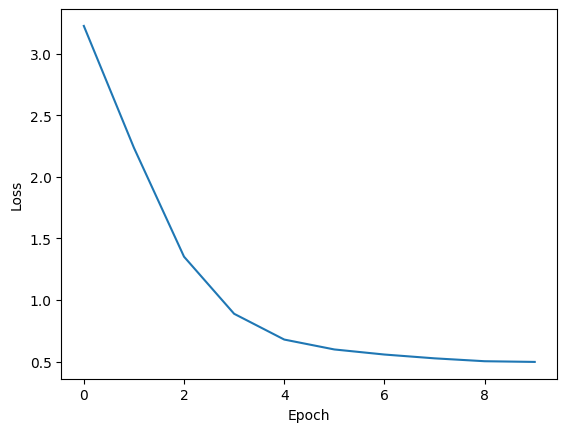

In [9]:
plot_loss(loss_vals, path="../figures/loss.png")